In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
df = pd.read_csv("health_activity_data(Dataset 2).csv")
df.head()

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Blood_Pressure,Exercise_Hours_per_Week,Smoker,Alcohol_Consumption_per_Week,Diabetic,Heart_Disease
0,1,56,Male,164,81,30.72,5134,1796,8.6,102,137/72,8.1,No,7,No,No
1,2,69,Male,156,82,20.86,12803,1650,4.5,103,129/65,3.7,No,7,No,No
2,3,46,Female,158,65,30.93,16408,1756,4.3,74,127/68,3.2,Yes,0,No,No
3,4,32,Male,197,87,31.19,18420,2359,4.1,116,125/86,8.5,No,5,No,No
4,5,60,Male,157,63,29.37,17351,2556,5.1,111,100/64,8.5,Yes,8,No,No


In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   str    
 3   Height_cm                     1000 non-null   int64  
 4   Weight_kg                     1000 non-null   int64  
 5   BMI                           1000 non-null   float64
 6   Daily_Steps                   1000 non-null   int64  
 7   Calories_Intake               1000 non-null   int64  
 8   Hours_of_Sleep                1000 non-null   float64
 9   Heart_Rate                    1000 non-null   int64  
 10  Blood_Pressure                1000 non-null   str    
 11  Exercise_Hours_per_Week       1000 non-null   float64
 12  Smoker                        1000 non-null   str    
 13  Alcohol_Consump

In [99]:
df['Gender_Male'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Smoker_Yes'] = df['Smoker'].map({'Yes': 1, 'No': 0})
df['Diabetic_Yes'] = df['Diabetic'].map({'Yes': 1, 'No': 0})
df['HeartDisease_Yes'] = df['Heart_Disease'].map({'Yes': 1, 'No': 0})    
df.drop(columns = ['ID','Gender', 'Smoker', 'Diabetic', 'Heart_Disease'], inplace=True) 

In [100]:
df['Blood_Pressure'] = df['Blood_Pressure'].str.split('/')
df['Systolic_BP'] = df['Blood_Pressure'].str[0].astype('int64')
df['Diastolic_BP'] = df['Blood_Pressure'].str[1].astype('int64')
df.drop(columns = ['Blood_Pressure'], inplace=True)

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           1000 non-null   int64  
 1   Height_cm                     1000 non-null   int64  
 2   Weight_kg                     1000 non-null   int64  
 3   BMI                           1000 non-null   float64
 4   Daily_Steps                   1000 non-null   int64  
 5   Calories_Intake               1000 non-null   int64  
 6   Hours_of_Sleep                1000 non-null   float64
 7   Heart_Rate                    1000 non-null   int64  
 8   Exercise_Hours_per_Week       1000 non-null   float64
 9   Alcohol_Consumption_per_Week  1000 non-null   int64  
 10  Gender_Male                   1000 non-null   int64  
 11  Smoker_Yes                    1000 non-null   int64  
 12  Diabetic_Yes                  1000 non-null   int64  
 13  HeartDisease_Ye

<Axes: >

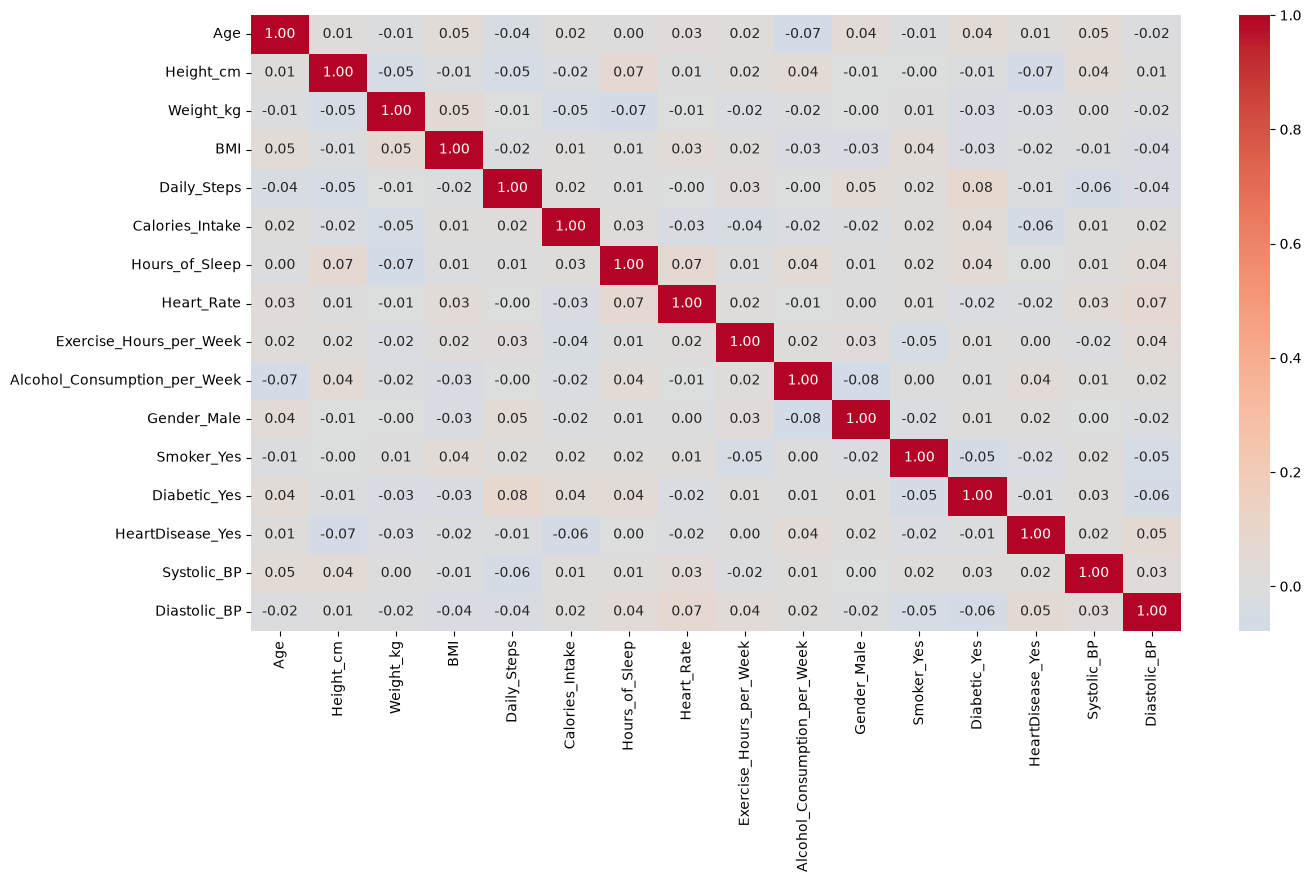

In [102]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)


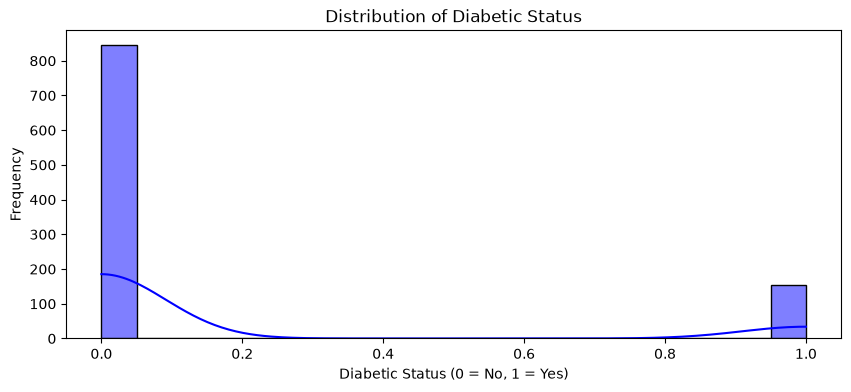

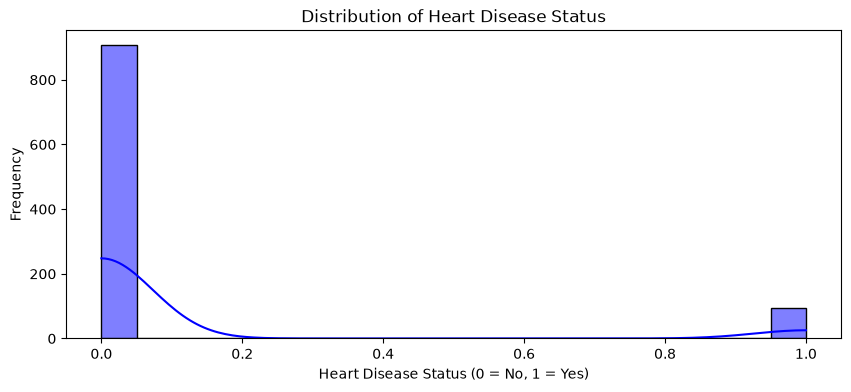

In [103]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Diabetic_Yes'], bins=20, kde=True, color='blue')
plt.title('Distribution of Diabetic Status')
plt.xlabel('Diabetic Status (0 = No, 1 = Yes)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(df['HeartDisease_Yes'], bins=20, kde=True, color='blue')
plt.title('Distribution of Heart Disease Status')
plt.xlabel('Heart Disease Status (0 = No, 1 = Yes)')
plt.ylabel('Frequency')
plt.show()

<Figure size 200x700 with 0 Axes>

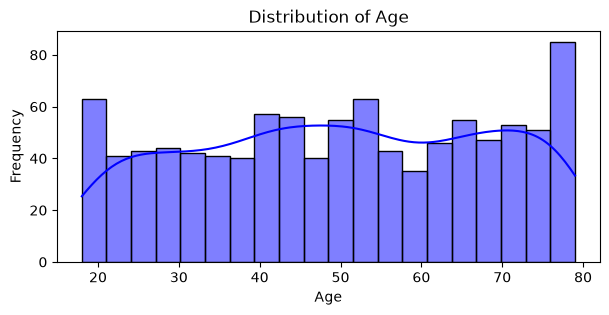

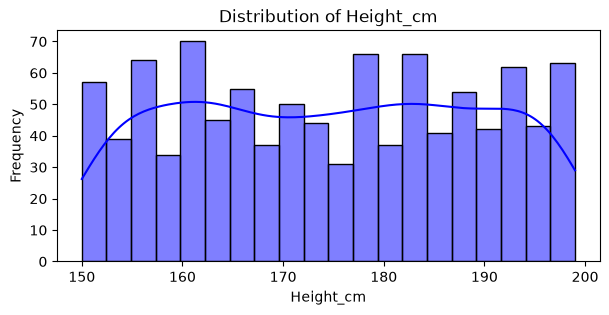

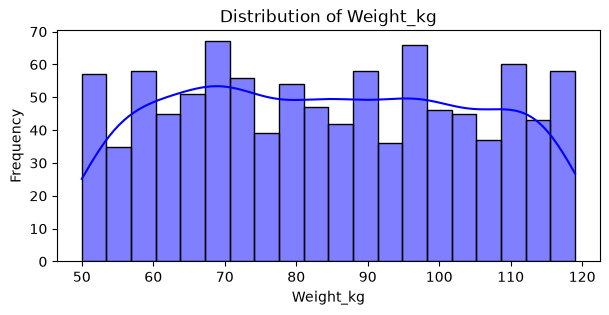

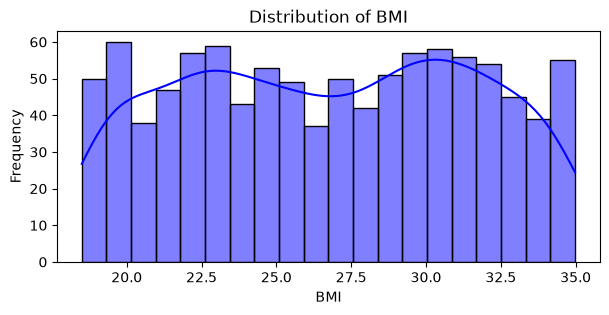

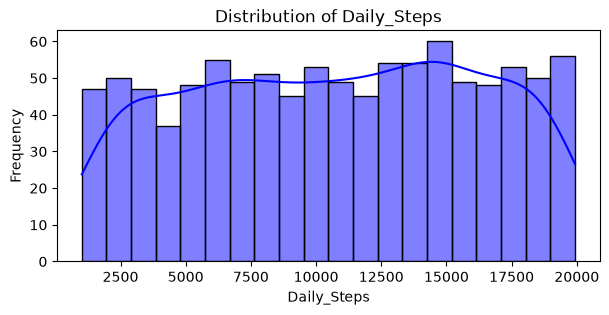

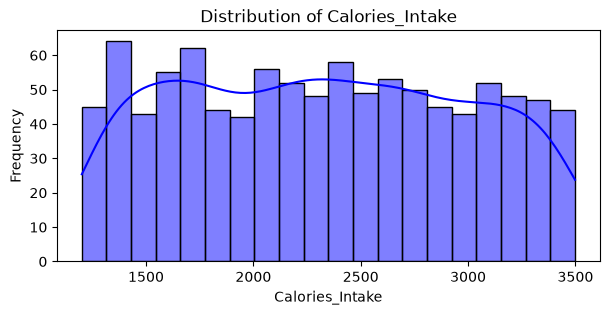

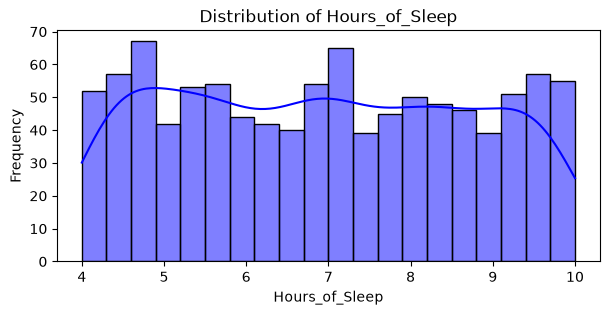

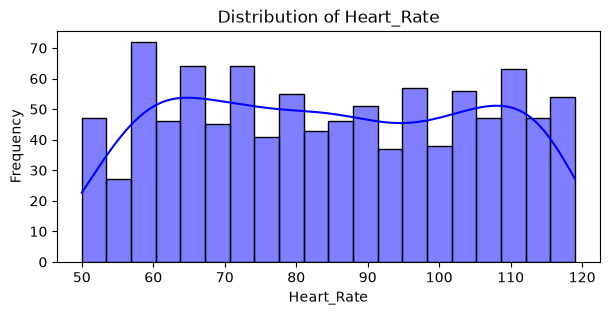

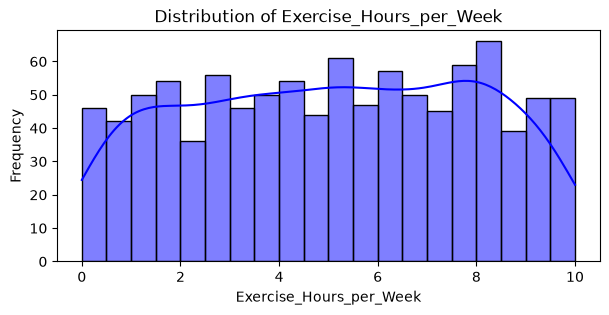

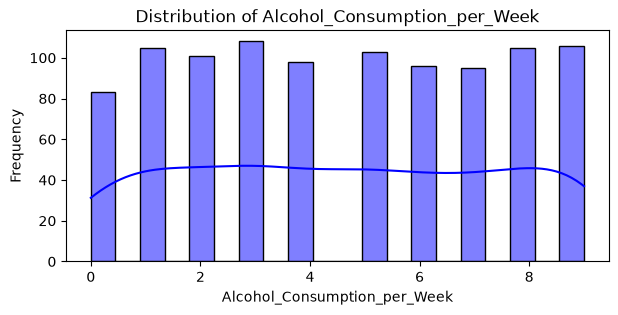

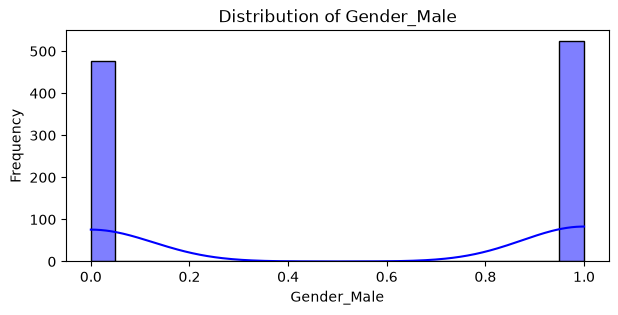

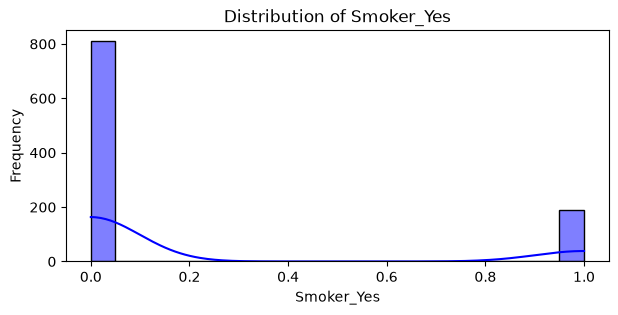

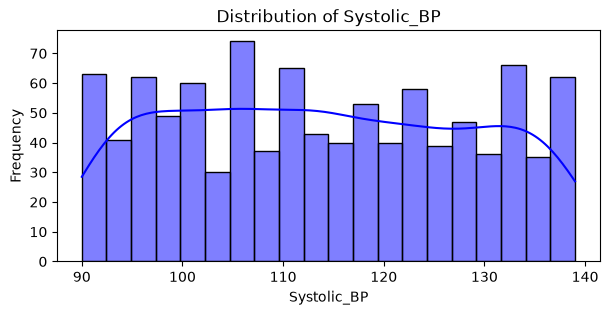

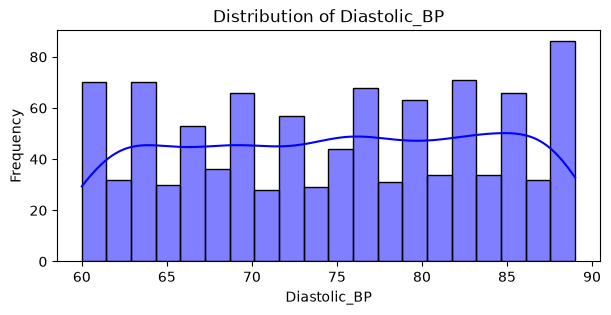

In [125]:
df2 = df.drop(columns=['Diabetic_Yes', 'HeartDisease_Yes'])
plt.figure(figsize=(2, 7))
for i, col in enumerate(df2.columns):
    plt.figure(figsize=(7, 3))
    sns.histplot(df2[col], bins=20 , kde= True, color='blue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

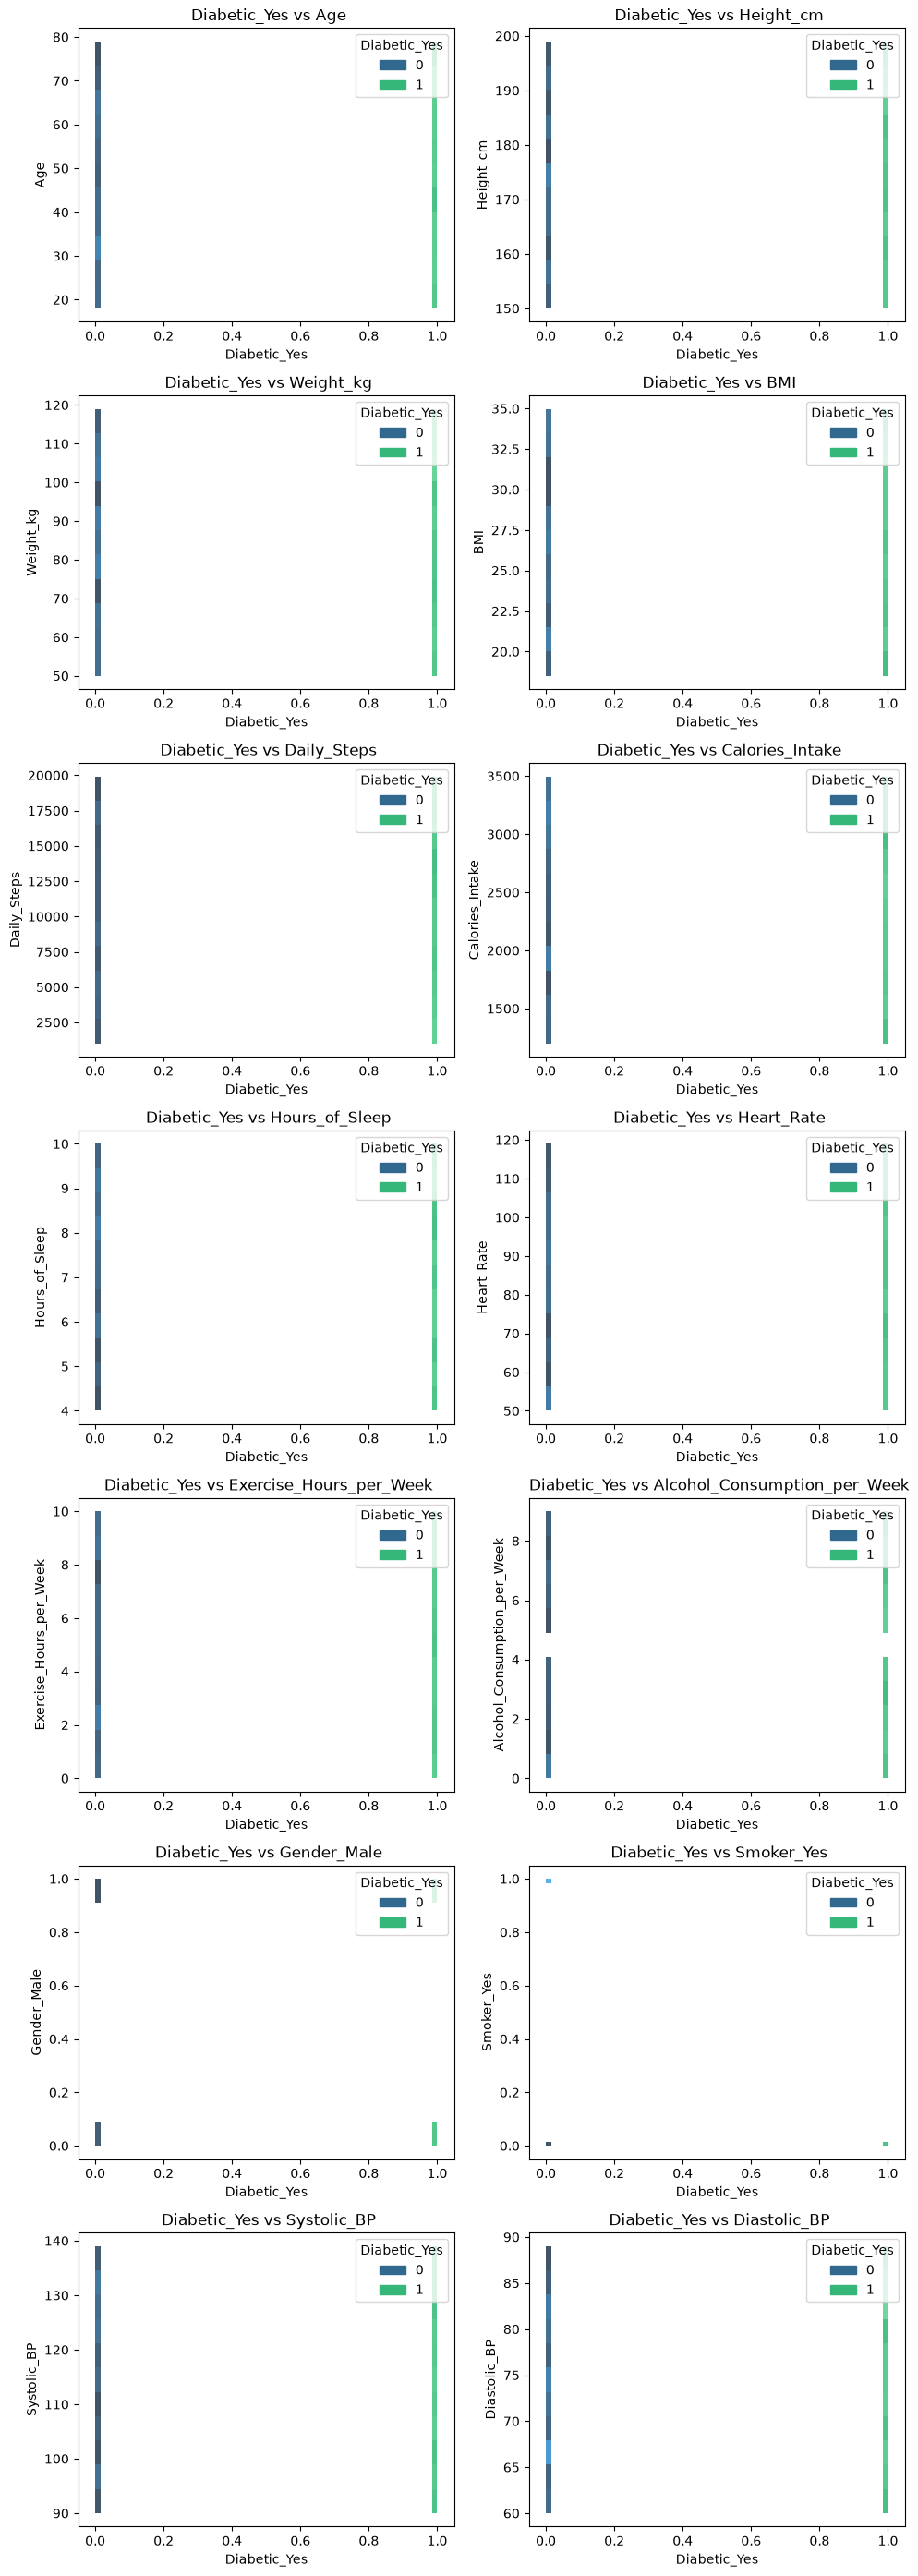

In [ ]:
plt.figure(figsize=(10, 4*7))
for i,colm in enumerate(df2.columns):
    plt.subplot(7, 2, i+1)
    sns.histplot(x=df['Diabetic_Yes'], y=df2[colm], hue = df['Diabetic_Yes'], palette="viridis")
    plt.title(f' Diabetic_Yes vs {colm}')
    plt.xlabel("Diabetic_Yes")
    plt.ylabel(colm)
plt.tight_layout()
plt.show()